# AFFC-Net + SUARA: Full Experiment Notebook
This notebook covers:
1. SUARA theoretical cost models and speedup analysis (BRACS gradient size)
2. Training command reference (BRACS dataset)
3. Loading results from all P/mode configurations
4. Classification metrics comparison table (AFFC-Net baseline vs AFFC+SUARA)
5. Training efficiency charts (epoch wall-time & allreduce speedup)
6. Full experiment summary

**Dataset:** BRACS (7 classes: 0_N, 1_PB, 2_UDH, 3_FEA, 4_ADH, 5_DCIS, 6_IC)  
**Feature files:** `bracs_cnn_features_ver2.pt`, `bracs_gnn_features_ver2.pt`, `bracs_labels_ver2.pt`


In [1]:
import os, sys, math, json, time
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

HOME = os.path.expanduser('~')

# BRACS 7-class metadata
NUM_CLASSES = 7
CLASS_NAMES = ['0_N', '1_PB', '2_UDH', '3_FEA', '4_ADH', '5_DCIS', '6_IC']
DATASET_TAG = 'bracs'

# Gradient message size estimate (~2.5 MB for AFFC-Net)
MS_BYTES = 2_500_000

print(f'Setup done. HOME = {HOME}')
print(f'BRACS classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Gradient message size (estimate): {MS_BYTES/1024:.1f} KB')


Setup done. HOME = /nfsshare/users/P126003189
BRACS classes (7): ['0_N', '1_PB', '2_UDH', '3_FEA', '4_ADH', '5_DCIS', '6_IC']
Gradient message size (estimate): 2441.4 KB


## 1. SUARA Theoretical Cost Models

In [2]:
def T_linear(P, m, a, b, g): return (P-1) * (2*(a + b*m) + g*m)
def T_nono(P, m, a, b, g):   return 2*(P-1)*a + 2*b*m*math.log2(P) + g*m*(P-1)/P
def T_rd(P, m, a, b, g):     return math.log2(P)*(a + b*m + g*m) if P > 1 else 0.0
def T_rnos(P, m, a, b, g):   return 2*(P-1)*a + 2*((P-1)/P)*b*m + ((P-1)/P)*g*m
def T_rab(P, m, a, b, g):    return (2*math.log2(P)*a + 2*((P-1)/P)*b*m + ((P-1)/P)*g*m) if P > 1 else 0.0

ALGO_FUNCS = {'linear': T_linear, 'nono': T_nono, 'rd': T_rd, 'rnos': T_rnos, 'rab': T_rab}

# Hockney model parameters (Shaheen-II, from SUARA paper)
H_PARAMS = {
    'linear': (1.5e-6, 6.25e-11), 'nono': (1.5e-6, 6.25e-11),
    'rd'    : (1.2e-6, 7.0e-11),  'rnos': (1.4e-6, 6.5e-11),
    'rab'   : (1.3e-6, 6.8e-11),
}
GAMMA = 2e-10

def native_ring_time(P, m):
    '''Native allreduce using ring (Open MPI default for large messages)'''
    a, b = H_PARAMS['rnos']
    return T_rnos(P, m, a, b, GAMMA)

def suara_optimal_time(P, m):
    '''SUARA: best 2D grid, each sub-group picks its own optimal algorithm'''
    best_time = float('inf')
    best_Pc   = 1
    for Pc in range(1, P + 1):
        if P % Pc != 0:
            continue
        Pr = P // Pc
        t_row = min(f(Pc, m, *H_PARAMS[a], GAMMA) for a, f in ALGO_FUNCS.items())
        t_col = min(f(Pr, m, *H_PARAMS[a], GAMMA) for a, f in ALGO_FUNCS.items())
        ts = t_row + t_col
        if ts < best_time:
            best_time = ts
            best_Pc   = Pc
    return best_time, best_Pc

print('Allreduce cost models defined.')
print(f'Message size: {MS_BYTES/1e6:.2f} MB')


Allreduce cost models defined.
Message size: 2.50 MB


## 2. Theoretical Speedup Table

In [3]:
P_values = [2, 4, 8, 16, 32, 64, 120, 128, 256, 512, 1024]

speedup_vals  = []
t_native_vals = []
t_suara_vals  = []
Pc_vals       = []

print(f"{'P':>6}  {'T_native(ms)':>14}  {'T_SUARA(ms)':>14}  {'Speedup':>9}  {'Pc*':>5}")
print('-' * 60)

for P in P_values:
    tn     = native_ring_time(P, MS_BYTES)
    ts, Pc = suara_optimal_time(P, MS_BYTES)
    sp     = tn / ts if ts > 0 else 1.0
    speedup_vals.append(sp)
    t_native_vals.append(tn * 1e3)
    t_suara_vals.append(ts * 1e3)
    Pc_vals.append(Pc)
    marker = '  <-- your cluster' if P == 120 else ''
    print(f"{P:>6}  {tn*1e3:>14.3f}  {ts*1e3:>14.3f}  {sp:>9.3f}x  {Pc:>5}{marker}")


     P    T_native(ms)     T_SUARA(ms)    Speedup    Pc*
------------------------------------------------------------
     2           0.415           0.415      1.000x      1
     4           0.627           0.627      1.000x      1
     8           0.741           0.741      1.000x      1
    16           0.815           0.798      1.022x      1
    32           0.886           0.827      1.072x      1
    64           0.989           0.842      1.173x      1
   120           1.151           0.851      1.353x      1  <-- your cluster
   128           1.174           0.852      1.379x      1
   256           1.536           0.858      1.791x      1
   512           2.254           0.862      2.616x      1
  1024           3.689           0.865      4.263x      1


## 3. Theoretical Speedup Plots

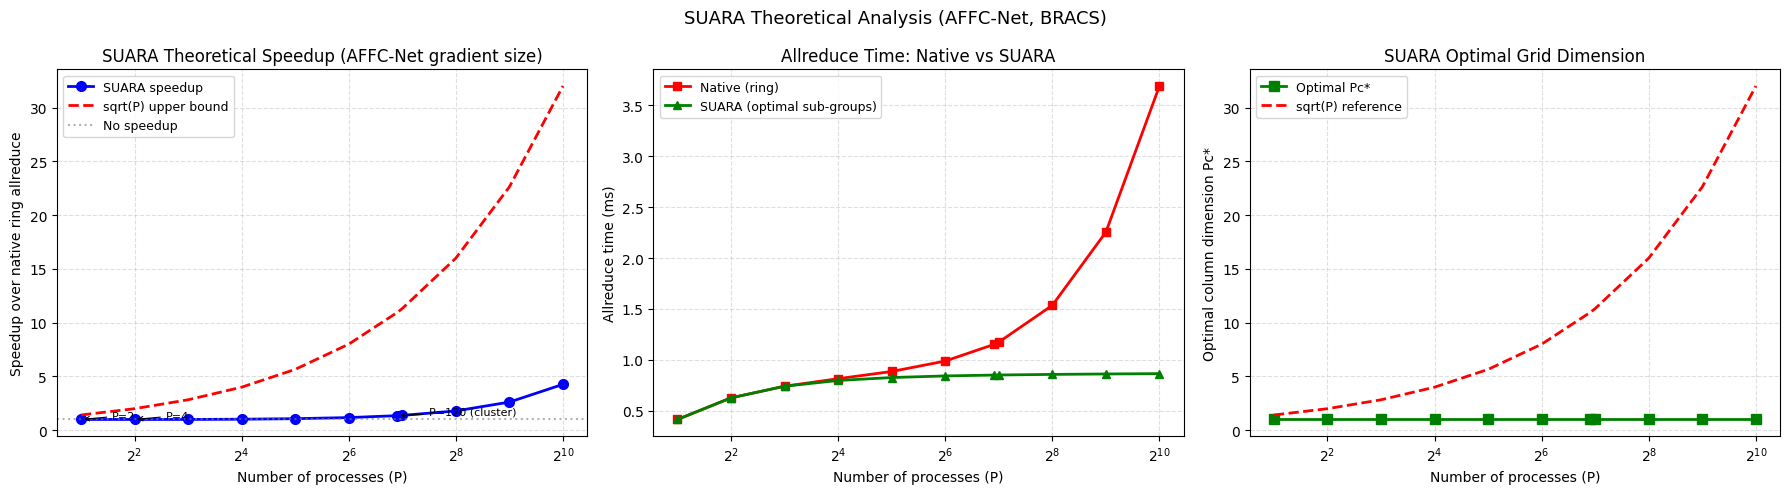

Saved -> /nfsshare/users/P126003189/suara_theoretical_speedup_bracs.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Speedup curve
ax = axes[0]
ax.plot(P_values, speedup_vals, 'bo-', lw=2, markersize=7, label='SUARA speedup')
ax.plot(P_values, [math.sqrt(P) for P in P_values], 'r--', lw=2, label='sqrt(P) upper bound')
ax.axhline(1.0, color='gray', ls=':', alpha=0.6, label='No speedup')
for P_mark, label_str in [(2, 'P=2'), (4, 'P=4'), (120, 'P=120 (cluster)')]:
    if P_mark in P_values:
        idx = P_values.index(P_mark)
        ax.annotate(label_str, xy=(P_mark, speedup_vals[idx]),
                    xytext=(P_mark * 1.5, speedup_vals[idx] + 0.08),
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Speedup over native ring allreduce')
ax.set_title('SUARA Theoretical Speedup (AFFC-Net gradient size)')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

# Plot B: Allreduce times
ax = axes[1]
ax.plot(P_values, t_native_vals, 'rs-', lw=2, markersize=6, label='Native (ring)')
ax.plot(P_values, t_suara_vals,  'g^-', lw=2, markersize=6, label='SUARA (optimal sub-groups)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Allreduce time (ms)')
ax.set_title('Allreduce Time: Native vs SUARA')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

# Plot C: Optimal Pc*
ax = axes[2]
ax.plot(P_values, Pc_vals, 'gs-', lw=2, markersize=7, label='Optimal Pc*')
ax.plot(P_values, [math.sqrt(P) for P in P_values], 'r--', lw=2, label='sqrt(P) reference')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of processes (P)')
ax.set_ylabel('Optimal column dimension Pc*')
ax.set_title('SUARA Optimal Grid Dimension')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4)

plt.suptitle('SUARA Theoretical Analysis (AFFC-Net, BRACS)', fontsize=13)
plt.tight_layout()
save_path = os.path.join(HOME, 'suara_theoretical_speedup_bracs.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved -> {save_path}')


## 4. Training Commands (BRACS)

In [5]:
# Run these in your cluster terminal using train_affcnet_suara_bracs.py
#
# P=1 baseline (no distributed)
# CUDA_VISIBLE_DEVICES=0 python ~/train_affcnet_suara_bracs.py --mode native --epochs 100 --no_dist
#
# P=2 native allreduce
# CUDA_VISIBLE_DEVICES=0,1 torchrun --nproc_per_node=2 ~/train_affcnet_suara_bracs.py --mode native --epochs 100
#
# P=4 native allreduce
# CUDA_VISIBLE_DEVICES=0,1,2,3 torchrun --nproc_per_node=4 ~/train_affcnet_suara_bracs.py --mode native --epochs 100
#
# P=2 SUARA
# CUDA_VISIBLE_DEVICES=0,1 torchrun --nproc_per_node=2 ~/train_affcnet_suara_bracs.py --mode suara --epochs 100
#
# P=4 SUARA
# CUDA_VISIBLE_DEVICES=0,1,2,3 torchrun --nproc_per_node=4 ~/train_affcnet_suara_bracs.py --mode suara --epochs 100
#
# Results are saved as: ~/results_{mode}_P{p}_bracs.json

print('Commands listed. Run on the cluster, then proceed to Load Results cell.')


Commands listed. Run on the cluster, then proceed to Load Results cell.


## 5. Load Results

In [6]:
results = {}

for mode in ['native', 'suara']:
    for p in [1, 2, 4]:
        # Try multiple version suffixes for backwards compatibility
        for ver_tag in ['', '_ver5', '_ver4', '_ver3']:
            fname = os.path.join(HOME, f'results{ver_tag}_{mode}_P{p}_bracs.json')
            if os.path.exists(fname):
                with open(fname) as f:
                    results[f'{mode}_P{p}'] = json.load(f)
                print(f'Loaded: {fname}')
                break
        else:
            print(f'Missing: results_{mode}_P{p}_bracs.json')

print(f'\nAvailable configs: {list(results.keys())}')

# Update MS_BYTES from actual gradient size if available
if 'native_P1' in results and 'grad_bytes' in results['native_P1']:
    MS_BYTES = results['native_P1']['grad_bytes']
    print(f'Updated MS_BYTES from actual model: {MS_BYTES/1024:.1f} KB')

# Show dataset split sizes
if 'native_P1' in results:
    r = results['native_P1']
    print(f"Dataset split — train: {r.get('train_size','?')}  "
          f"val: {r.get('val_size','?')}  test: {r.get('test_size','?')}")


Loaded: /nfsshare/users/P126003189/results_ver5_native_P1_bracs.json
Loaded: /nfsshare/users/P126003189/results_ver5_native_P2_bracs.json
Loaded: /nfsshare/users/P126003189/results_ver5_native_P4_bracs.json
Missing: results_suara_P1_bracs.json
Loaded: /nfsshare/users/P126003189/results_ver5_suara_P2_bracs.json
Loaded: /nfsshare/users/P126003189/results_ver5_suara_P4_bracs.json

Available configs: ['native_P1', 'native_P2', 'native_P4', 'suara_P2', 'suara_P4']
Updated MS_BYTES from actual model: 7131.5 KB
Dataset split — train: 2911  val: 624  test: 624


## 6. Classification Metrics + Training Efficiency Table

In [7]:
METRIC_KEYS   = ['acc', 'prec', 'recall', 'spec', 'f1']
METRIC_LABELS = ['Acc', 'Prec', 'Rec',    'Spec', 'F1']

print('=' * 95)
print('Part A  Classification Metrics  (BRACS — 7-class)')
print('=' * 95)
print(f"{'Config':<32} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'Spec':>8} {'F1':>8}")
print('-' * 95)

ROWS = [
    ('AFFC-Net Baseline (native, P=1)',  'native_P1'),
    ('AFFC-Net          (native, P=2)',  'native_P2'),
    ('AFFC-Net          (native, P=4)',  'native_P4'),
    ('AFFC-Net + SUARA  (P=2)',          'suara_P2'),
    ('AFFC-Net + SUARA  (P=4)',          'suara_P4'),
]
for label, key in ROWS:
    if key in results:
        r    = results[key]
        vals = [r[f'test_{m}'] * 100 for m in METRIC_KEYS]
        print(f"{label:<32} " + '  '.join(f"{v:>7.2f}%" for v in vals))
    else:
        print(f"{label:<32}  -- not yet run --")

print('=' * 95)

print()
print('=' * 68)
print('Part B  Training Efficiency  — Epoch Wall-Time  (BRACS)')
print('=' * 68)
print(f"{'Config':<28} {'avg epoch(s)':>13} {'EP speedup':>11} {'AR time(s)':>12}")
print('-' * 68)

base_ep = results.get('native_P1', {}).get('avg_epoch_time')

for p in [1, 2, 4]:
    for mode in ['native', 'suara']:
        key = f'{mode}_P{p}'
        if p == 1 and mode == 'suara':
            continue
        if key not in results:
            continue
        r = results[key]
        ep_sp = f"{base_ep / r['avg_epoch_time']:.2f}x" if base_ep else '--'
        ar_t  = r.get('avg_ar_time', 0.0)
        print(f"{key:<28} {r['avg_epoch_time']:>13.2f} {ep_sp:>11} {ar_t:>12.4f}")

print('=' * 68)
print('  EP speedup: relative to AFFC-Net native P=1 baseline')
print('  AR time: avg per-epoch allreduce communication time (comms only)')

print()
print('─' * 68)
print('Part C  Allreduce Speedup: SUARA vs Native (same P)')
print('─' * 68)
for p in [2, 4]:
    nk = f'native_P{p}'; sk = f'suara_P{p}'
    if nk in results and sk in results:
        nat_ar = results[nk].get('avg_ar_time', 0)
        sua_ar = results[sk].get('avg_ar_time', 0)
        ar_sp  = nat_ar / sua_ar if sua_ar > 0 else float('nan')
        print(f"  P={p}: Native AR={nat_ar:.4f}s  SUARA AR={sua_ar:.4f}s  "
              f"AR speedup={ar_sp:.3f}x")


Part A  Classification Metrics  (BRACS — 7-class)
Config                                Acc     Prec      Rec     Spec       F1
-----------------------------------------------------------------------------------------------
AFFC-Net Baseline (native, P=1)    57.05%    55.78%    55.79%    92.80%    55.63%
AFFC-Net          (native, P=2)    58.97%    56.08%    57.85%    93.12%    56.37%
AFFC-Net          (native, P=4)    55.61%    55.58%    55.77%    92.67%    54.58%
AFFC-Net + SUARA  (P=2)            59.94%    58.19%    59.39%    93.29%    57.76%
AFFC-Net + SUARA  (P=4)            57.85%    55.41%    54.88%    92.86%    54.87%

Part B  Training Efficiency  — Epoch Wall-Time  (BRACS)
Config                        avg epoch(s)  EP speedup   AR time(s)
--------------------------------------------------------------------
native_P1                             8.19       1.00x       0.0000
native_P2                             5.17       1.58x       4.0429
suara_P2                            

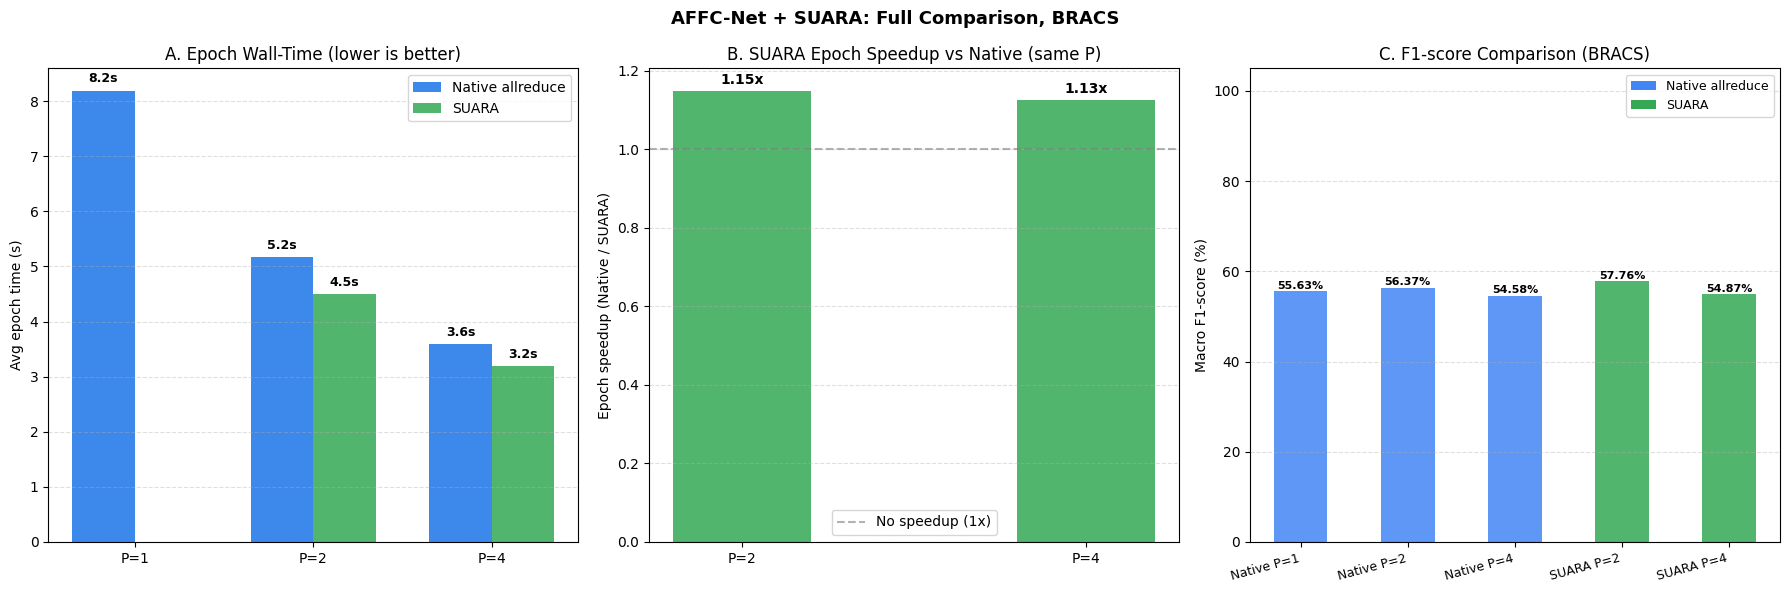

Saved -> /nfsshare/users/P126003189/suara_final_comparison_bracs.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart A: Epoch wall-time
ax = axes[0]
p_vals  = [1, 2, 4]
ep_nat  = [results.get(f'native_P{p}', {}).get('avg_epoch_time') for p in p_vals]
ep_sua  = [None] + [results.get(f'suara_P{p}', {}).get('avg_epoch_time') for p in [2, 4]]
x = np.arange(len(p_vals)); w = 0.35
b1 = ax.bar(x - w/2, [v if v else 0 for v in ep_nat], w,
            label='Native allreduce', color='#1a73e8', alpha=0.85)
b2 = ax.bar(x + w/2, [v if v else 0 for v in ep_sua], w,
            label='SUARA', color='#34a853', alpha=0.85)
for bar, val in list(zip(b1, ep_nat)) + list(zip(b2, ep_sua)):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'P={p}' for p in p_vals])
ax.set_ylabel('Avg epoch time (s)')
ax.set_title('A. Epoch Wall-Time (lower is better)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)

# Chart B: Epoch speedup (SUARA vs Native, same P)
ax = axes[1]
p_comp = [2, 4]
ep_speedups = []
for p in p_comp:
    nat = results.get(f'native_P{p}', {}).get('avg_epoch_time')
    sua = results.get(f'suara_P{p}',  {}).get('avg_epoch_time')
    ep_speedups.append(nat / sua if nat and sua else 0)

x2 = np.arange(len(p_comp))
bars = ax.bar(x2, ep_speedups, color='#34a853', alpha=0.85, width=0.4)
ax.axhline(1.0, color='gray', ls='--', alpha=0.6, label='No speedup (1x)')
for bar, val in zip(bars, ep_speedups):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x2); ax.set_xticklabels([f'P={p}' for p in p_comp])
ax.set_ylabel('Epoch speedup (Native / SUARA)')
ax.set_title('B. SUARA Epoch Speedup vs Native (same P)')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)

# Chart C: F1 comparison bar chart
ax = axes[2]
cfg_labels = []
f1_vals    = []
colors     = []
for label, key, color in [
    ('Native P=1', 'native_P1', '#4285f4'),
    ('Native P=2', 'native_P2', '#4285f4'),
    ('Native P=4', 'native_P4', '#4285f4'),
    ('SUARA P=2',  'suara_P2',  '#34a853'),
    ('SUARA P=4',  'suara_P4',  '#34a853'),
]:
    if key in results:
        cfg_labels.append(label)
        f1_vals.append(results[key]['test_f1'] * 100)
        colors.append(color)

if f1_vals:
    xc = np.arange(len(cfg_labels))
    bars_f1 = ax.bar(xc, f1_vals, color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars_f1, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(xc); ax.set_xticklabels(cfg_labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Macro F1-score (%)')
    ax.set_title('C. F1-score Comparison (BRACS)')
    ax.set_ylim(0, 105)
    ax.grid(axis='y', ls='--', alpha=0.4)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#4285f4', label='Native allreduce'),
        Patch(facecolor='#34a853', label='SUARA'),
    ], fontsize=9)
else:
    ax.text(0.5, 0.5, 'No results loaded yet', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color='gray')
    ax.set_title('C. F1-score Comparison (BRACS)')

plt.suptitle('AFFC-Net + SUARA: Full Comparison, BRACS', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(HOME, 'suara_final_comparison_bracs.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved -> {save_path}')


## 7. Per-Class Performance Analysis (BRACS 7-class)

In [9]:
if not results:
    print('No results loaded. Run training first.')
else:
    print('Classification summary across all BRACS configs:')
    print(f"{'Config':<28} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'Spec':>8} {'F1':>8}")
    print('-' * 75)
    for label, key in [
        ('AFFC-Net (native, P=1)', 'native_P1'),
        ('AFFC-Net (native, P=2)', 'native_P2'),
        ('AFFC-Net (native, P=4)', 'native_P4'),
        ('AFFC + SUARA  (P=2)',    'suara_P2'),
        ('AFFC + SUARA  (P=4)',    'suara_P4'),
    ]:
        if key in results:
            r = results[key]
            print(f"{label:<28} "
                  f"{r['test_acc']*100:>7.2f}%  "
                  f"{r['test_prec']*100:>7.2f}%  "
                  f"{r['test_recall']*100:>7.2f}%  "
                  f"{r['test_spec']*100:>7.2f}%  "
                  f"{r['test_f1']*100:>7.2f}%")

    # Delta: SUARA P=2 vs Native P=2
    if 'native_P2' in results and 'suara_P2' in results:
        print()
        print('SUARA improvement over native (same P=2):')
        for mk in ['test_acc', 'test_f1', 'test_recall', 'test_spec']:
            delta = (results['suara_P2'][mk] - results['native_P2'][mk]) * 100
            sign  = '+' if delta >= 0 else ''
            print(f"  {mk:<18}: {sign}{delta:.3f}%")


Classification summary across all BRACS configs:
Config                            Acc     Prec      Rec     Spec       F1
---------------------------------------------------------------------------
AFFC-Net (native, P=1)         57.05%    55.78%    55.79%    92.80%    55.63%
AFFC-Net (native, P=2)         58.97%    56.08%    57.85%    93.12%    56.37%
AFFC-Net (native, P=4)         55.61%    55.58%    55.77%    92.67%    54.58%
AFFC + SUARA  (P=2)            59.94%    58.19%    59.39%    93.29%    57.76%
AFFC + SUARA  (P=4)            57.85%    55.41%    54.88%    92.86%    54.87%

SUARA improvement over native (same P=2):
  test_acc          : +0.962%
  test_f1           : +1.390%
  test_recall       : +1.537%
  test_spec         : +0.179%


## 8. Experiment Summary

In [10]:
print('\n' + '=' * 75)
print('EXPERIMENT SUMMARY -- AFFC-Net + SUARA | BRACS Dataset')
print('=' * 75)

if 'native_P1' in results:
    r1 = results['native_P1']
    print('\nAFFC-Net Baseline (P=1, single GPU):')
    for mk, ml in zip(['acc','prec','recall','spec','f1'],
                      ['Accuracy','Precision','Recall','Specificity','F1-score']):
        print(f'  {ml:<14}: {r1["test_" + mk]*100:.2f}%')
    print(f"  Epoch time  : {r1['avg_epoch_time']:.2f}s")
    if 'grad_bytes' in r1:
        print(f"  Grad buffer : {r1['grad_bytes']/1024:.1f} KB")
    print(f"  Train/Val/Test: {r1.get('train_size','?')} / "
          f"{r1.get('val_size','?')} / {r1.get('test_size','?')}")
else:
    print('\n[No baseline results loaded yet]')

configs = [
    ('native_P2', 'Native P=2'),
    ('native_P4', 'Native P=4'),
    ('suara_P2',  'SUARA P=2'),
    ('suara_P4',  'SUARA P=4'),
]
for cfg_key, cfg_label in configs:
    if cfg_key in results:
        r = results[cfg_key]
        print(f'\n{cfg_label}:')
        print(f"  F1={r['test_f1']*100:.2f}%  Acc={r['test_acc']*100:.2f}%  "
              f"epoch={r['avg_epoch_time']:.2f}s  ar={r.get('avg_ar_time',0):.4f}s")

print('\n' + '-' * 75)
print('Epoch speedup (SUARA vs Native, same P):')
base_ep = results.get('native_P1', {}).get('avg_epoch_time')
for p in [2, 4]:
    nk = f'native_P{p}'; sk = f'suara_P{p}'
    if nk in results and sk in results:
        ep_sp = results[nk]['avg_epoch_time'] / results[sk]['avg_epoch_time']
        ep_vs_p1 = base_ep / results[sk]['avg_epoch_time'] if base_ep else None
        p1_str = f"  vs P=1 baseline: {ep_vs_p1:.2f}x" if ep_vs_p1 else ""
        print(f'  P={p}: Epoch speedup={ep_sp:.3f}x{p1_str}')

print('\n' + '-' * 75)
print('Allreduce speedup (SUARA vs Native, same P):')
for p in [2, 4]:
    nk = f'native_P{p}'; sk = f'suara_P{p}'
    if nk in results and sk in results:
        nat_ar = results[nk].get('avg_ar_time', 0)
        sua_ar = results[sk].get('avg_ar_time', 0)
        if sua_ar > 0:
            ar_sp = nat_ar / sua_ar
            print(f'  P={p}: AR speedup={ar_sp:.3f}x  '
                  f'(native={nat_ar:.4f}s  suara={sua_ar:.4f}s)')

print('=' * 75)



EXPERIMENT SUMMARY -- AFFC-Net + SUARA | BRACS Dataset

AFFC-Net Baseline (P=1, single GPU):
  Accuracy      : 57.05%
  Precision     : 55.78%
  Recall        : 55.79%
  Specificity   : 92.80%
  F1-score      : 55.63%
  Epoch time  : 8.19s
  Grad buffer : 7131.5 KB
  Train/Val/Test: 2911 / 624 / 624

Native P=2:
  F1=56.37%  Acc=58.97%  epoch=5.17s  ar=4.0429s

Native P=4:
  F1=54.58%  Acc=55.61%  epoch=3.59s  ar=2.5460s

SUARA P=2:
  F1=57.76%  Acc=59.94%  epoch=4.50s  ar=0.0225s

SUARA P=4:
  F1=54.87%  Acc=57.85%  epoch=3.19s  ar=0.0137s

---------------------------------------------------------------------------
Epoch speedup (SUARA vs Native, same P):
  P=2: Epoch speedup=1.149x  vs P=1 baseline: 1.82x
  P=4: Epoch speedup=1.127x  vs P=1 baseline: 2.57x

---------------------------------------------------------------------------
Allreduce speedup (SUARA vs Native, same P):
  P=2: AR speedup=180.015x  (native=4.0429s  suara=0.0225s)
  P=4: AR speedup=185.741x  (native=2.5460s  sua

In [ ]:
# End of notebook
